# Fast, storage-free optimiser test

This notebook loads `sandbox/cheap_test.yaml`, runs the production physics and Adam kernels entirely in memory, and displays the standard three figures. It deliberately never calls the production runner, result store, or SQLite reader.

In [28]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

ROOT = Path.cwd().resolve()
if ROOT.name == "sandbox":
    ROOT = ROOT.parent
if not (ROOT / "src" / "ofc").is_dir():
    raise RuntimeError("Run this notebook from the repository root or sandbox directory.")

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "sandbox"))
CONFIG_PATH = ROOT / "sandbox" / "cheap_test.yaml"
CONFIG_PATH

PosixPath('/home/gyqyan/charlie/optical-feshbach-control/sandbox/cheap_test.yaml')

In [29]:
from ofc.config import load_config
from ofc.plotting import plot_standard_figures
from in_memory_runner import run_config_in_memory

document = load_config(CONFIG_PATH)
case = document.scalar_cases()[0]
{
    "name": document.name,
    "N": case.N,
    "T": case.t_interval,
    "r_bg": case.r_bg,
    "initialisations": document.runtime.initialisations,
    "total_steps": sum(steps for steps, _ in case.schedule),
}

{'name': 'sandbox_cheap_test',
 'N': 100,
 'T': 4.0,
 'r_bg': -0.008716,
 'initialisations': 10,
 'total_steps': 100000}

In [30]:
def fingerprint(path):
    return (path.exists(), path.stat().st_size, path.stat().st_mtime_ns) if path.exists() else (False, None, None)

configured_database = (ROOT / document.runtime.database).resolve()
database_before = fingerprint(configured_database)
document, runs = run_config_in_memory(document)
database_after = fingerprint(configured_database)
assert database_after == database_before, "The sandbox database sentinel changed."

best = max(runs, key=lambda run: run["best_score"])
{
    "database_unchanged": database_after == database_before,
    "runs": len(runs),
    "best_initialisation": best["initialization_index"],
    "best_step": best["best_step"],
    "best_score": best["best_score"],
    "best_molecular_objective": best["best_objective"],
    "best_penalty": best["best_penalty"],
}

{'database_unchanged': True,
 'runs': 10,
 'best_initialisation': 5,
 'best_step': 100000,
 'best_score': 1057.2687181124543,
 'best_molecular_objective': 1058.2375292194467,
 'best_penalty': 0.9688111069925135}

convergence


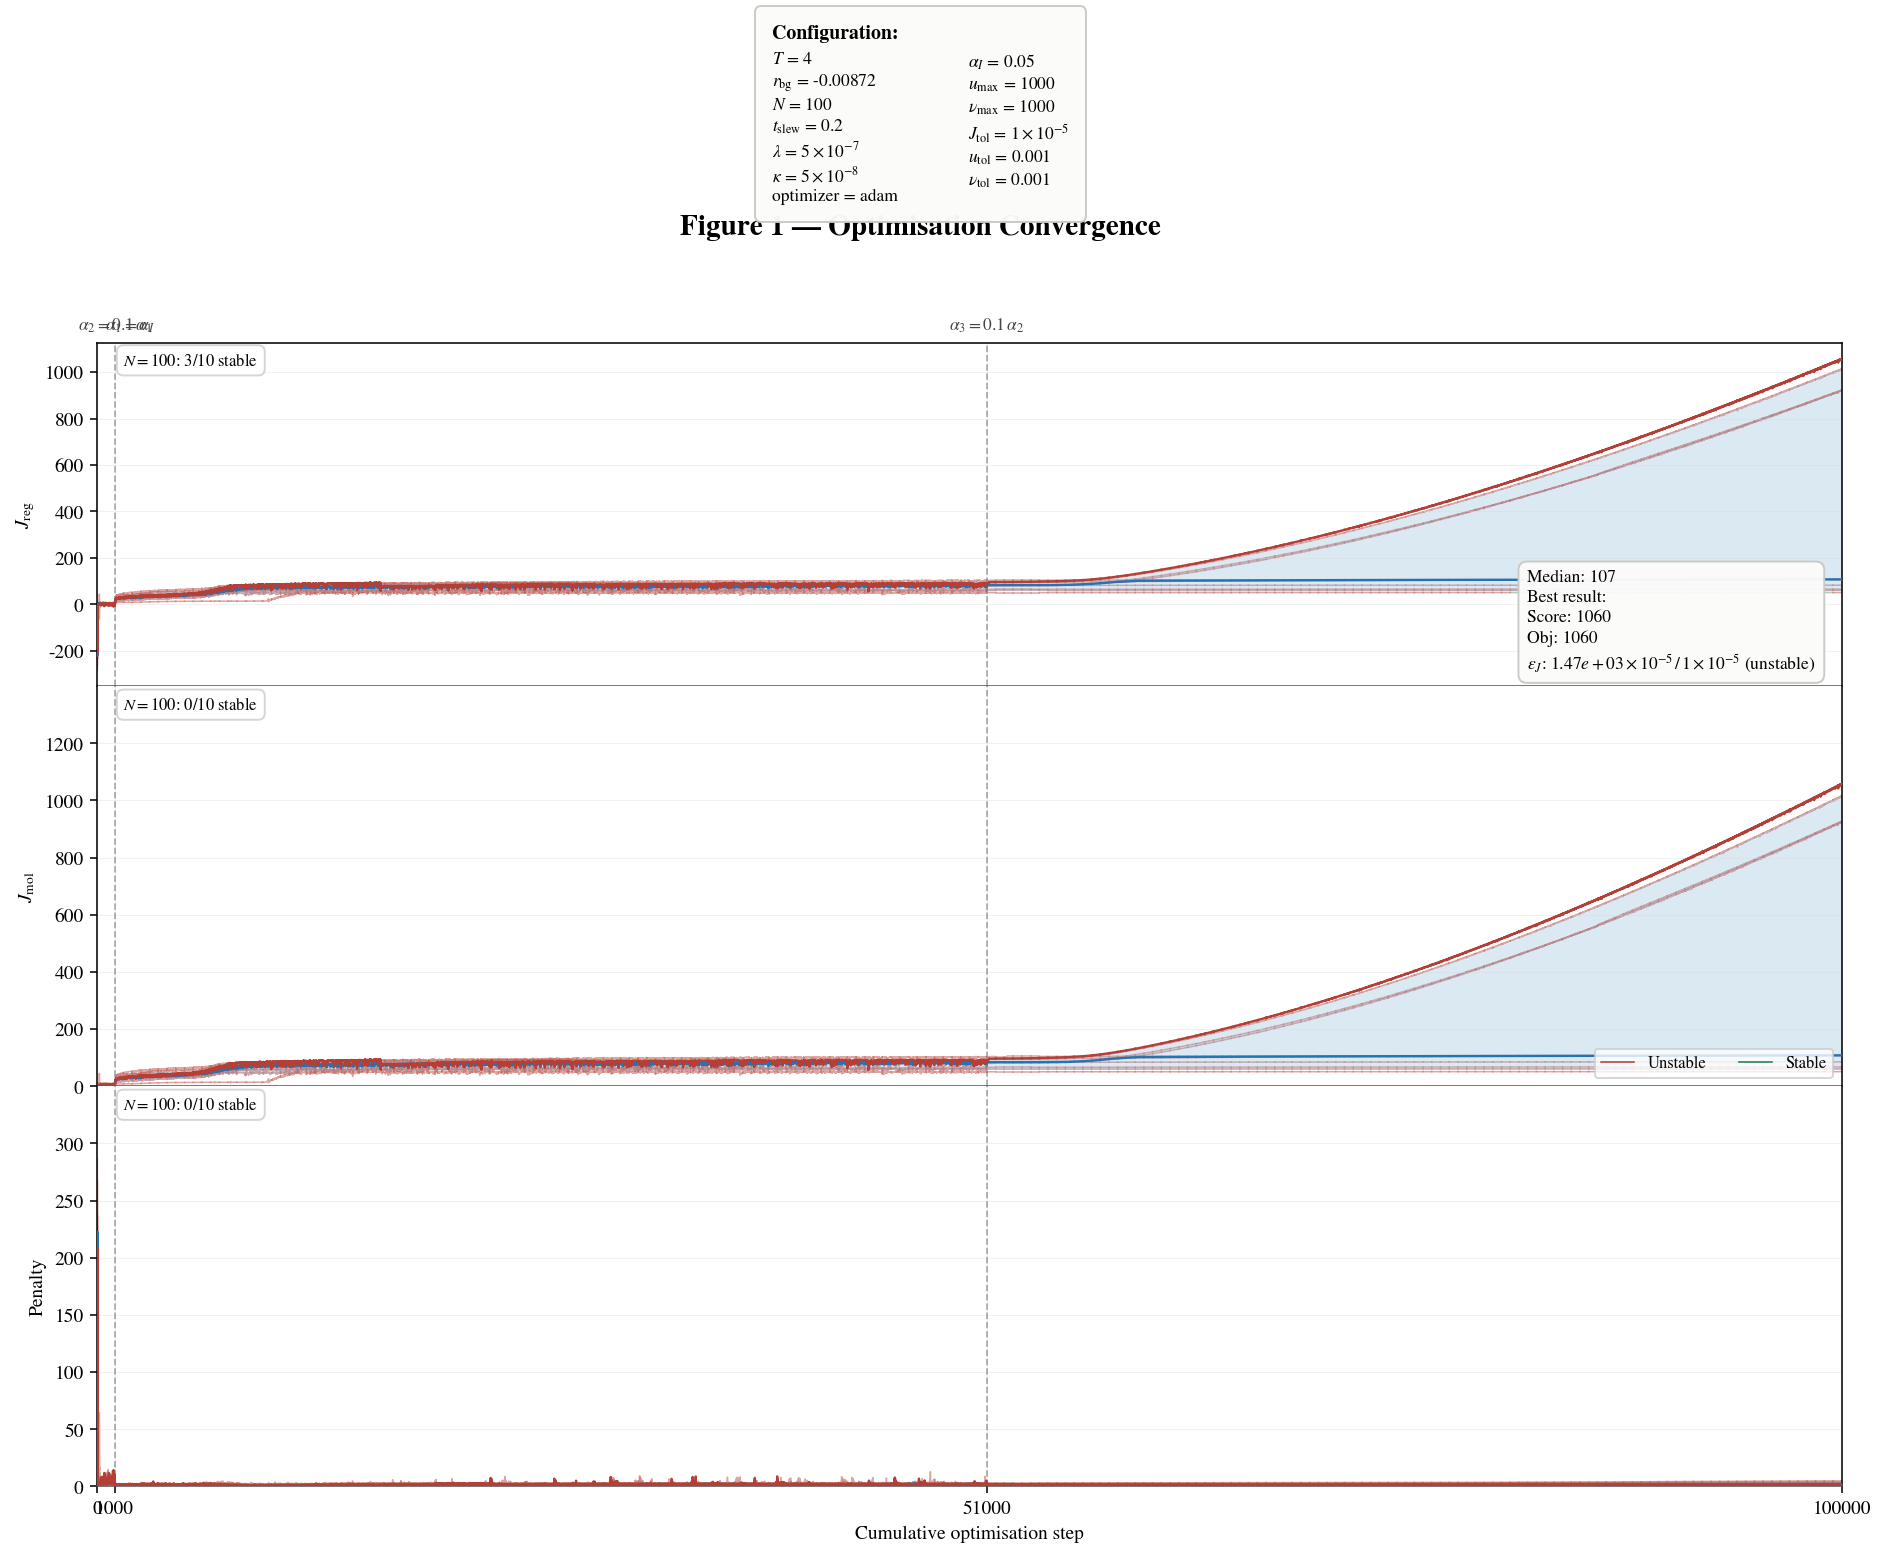

distribution


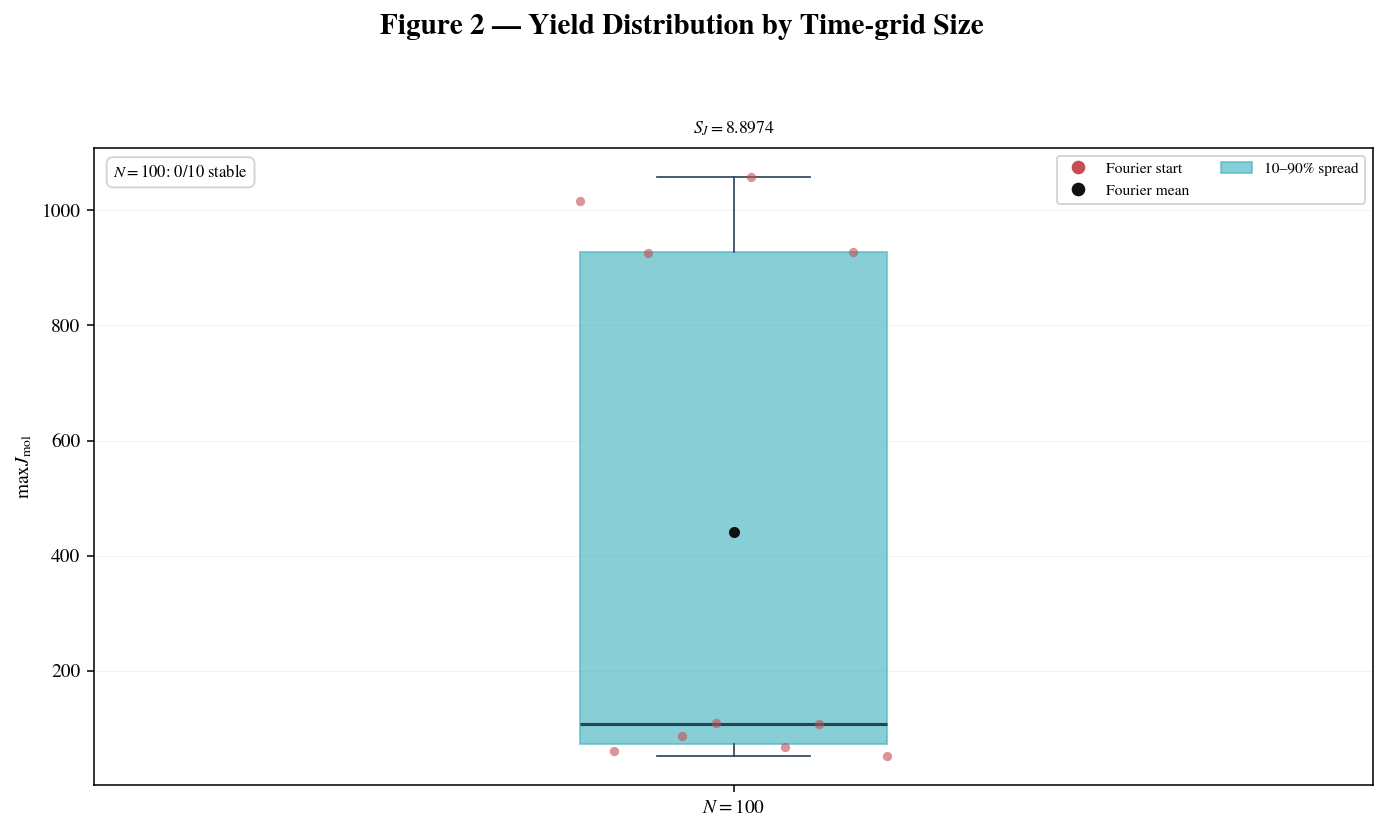

controls


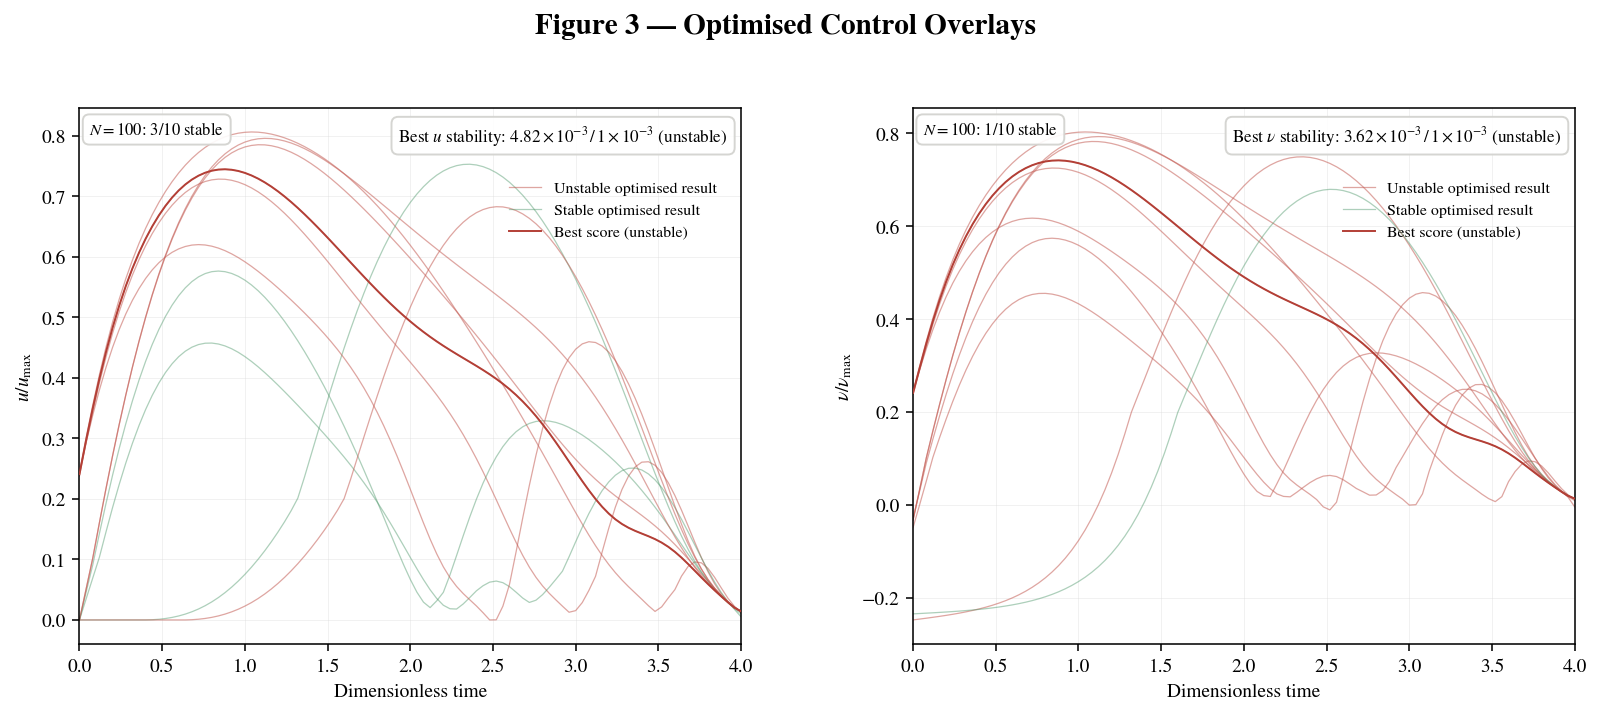

In [31]:
from io import BytesIO
from IPython.display import Image, display
import matplotlib.pyplot as plt

figures = plot_standard_figures(runs)
for name, (figure, _) in figures.items():
    print(name)
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(figure)